## Phase 1 – Annotationsstudie
Die Annotationsstudie prüft anhand einer festgelegten Stichprobe, in welchem Umfang die auf Volltextebene annotierten SemEval-Policy-Frames bereits auf Ebende der Nachrichtentitel erkennbar sind. Hierzu werden menschliche und LLM-basierte Titelannotationen miteinander sowie mit den SemEval-Volltextannotationen verglichen.

## Notebook B - Auswertung
### Verortung im *Gesamtprojekt*
Dieses Notebook wertet die Annotationsstudie aus.

1. Es liest die vollständig annotierten Sample Dateien aus *01c Annotierte Dateien* ein.
2. Es erzeugt die SemEval-Volltext-Ground-Truth deterministisch aus den Train-/Dev-Label-Dateien in *01a Rohdaten*
3. Es gleicht die annotierten Daten mit der Ground Truth ab und berechnet die ensprechenden Kennzwahlen und Metriken.
4. Es speichert die Auswertung in *01c Annotierte Daten*.

## Untersuchungsgegenstand
Die Stichprobe wird aus den Artikel-IDs der bereits annotierten Dateien rekonstruiert. Alle Dateien müssen exakt dieselben IDs enthalten; andernfalls bricht das Notebook mit einer verständlichen Fehlermeldung ab.

Geprüft werden:
1. die Übereinstimmung der menschlichen Annotierenden untereinander;
2. die Übereinstimmung der LLM-Konfigurationen untereinander;
3. die Überlappung menschlicher und LLM-basierter Titelannotation mit der SemEval-Volltextannotation;
4. Frames, bei denen Menschen oder LLMs besonders hohe beziehungsweise niedrige Agreement- und Leistungswerte erreichen;
5. Unterschiede nach Ursprungssprache der Artikel.

Die Auswertung erfolgt in zwei Varianten:
1. ursprüngliches Schema `0 = nicht vorhanden`, `1 = weiterer Frame`, `2 = primärer Frame` für das Interrater Agreement;

2. binäre Frame-Präsenz, wobei `1` und `2` zu `1` zusammengeführt werden, für die zentrale Multi-Label-Auswertung.


## Methodische Einordnung
SemEval stellt eine **Volltextreferenz** bereit, keinen unabhängigen Titel-Goldstandard. Precision, Recall und F1 gegenüber SemEval messen daher die Überlappung zwischen Titel- und Volltextebene.
Ein niedriger Recall kann bedeuten, dass ein Volltextframe im Titel nicht sichtbar ist; er ist nicht automatisch ein Fehler der Titelannotation.








In [4]:
# Benötigte Pakete in Colab installieren
!pip -q install krippendorff openpyxl statsmodels scikit-learn


In [5]:
from pathlib import Path
from collections import defaultdict
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import krippendorff
from IPython.display import display, Markdown
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

## 1. Drive einbinden und Pfade konfigurieren

Der Projektordner **von neu** liegt direkt auf der Ebene **Meine Ablage**. Notebook B greift nur auf die Rohdaten in `01a`, die bereits annotierte Stichprobe in `01c` und den Ergebnisordner `01d` zu. `01b Aufbereitete Daten` wird für diese Auswertung nicht benötigt.


In [6]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Ausführung außerhalb von Google Colab – Drive wurde nicht eingebunden.')

PROJECT_ROOT = Path('/content/drive/MyDrive/von neu')
PHASE_DIR = PROJECT_ROOT / '01 Annotationsstudie'
RAW_DIR = PHASE_DIR / '01a Rohdaten'
ANNOTATED_DIR = PHASE_DIR / '01c Annotierte Daten'
RESULTS_DIR = PHASE_DIR / '01d Ergebnisse'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

ID_COLUMN = 'Filename'
TITLE_COLUMN = 'Headline_GER'
LANGUAGE_COLUMN = 'Language'
EXPECTED_SAMPLE_SIZE = 210

GROUND_TRUTH_FULL_FILE = ANNOTATED_DIR / 'ground_truth_full.xlsx'
GROUND_TRUTH_SAMPLE_FILE = ANNOTATED_DIR / 'sample_groundtruth_volltext.xlsx'

HUMAN_FILES = [
    ANNOTATED_DIR / 'headlines_dataset_15sample_annotiert_alvaro.xlsx',
    ANNOTATED_DIR / 'headlines_dataset_15sample_annotiert_Felix.xlsx',
    ANNOTATED_DIR / 'headlines_dataset_15sample_annotiert_Tai.xlsx',
]

LLM_FILES = [
    ANNOTATED_DIR / 'headlines_dataset_15sample_LLM_annotiert_ChatGPT_5.6Luna.xlsx',
    ANNOTATED_DIR / 'headlines_dataset_15sample_LLM_annotiert_ChatGPTPlus_5.6Sol.xlsx',
    ANNOTATED_DIR / 'headlines_dataset_15sample_LLM_annotiert_Gemini_3.6Flash.xlsx',
    ANNOTATED_DIR / 'headlines_dataset_15sample_LLM_annotiert_Claude_Sonnet5.xlsx',
]

FRAME_COLUMNS = [
    'Economic',
    'Capacity and resources',
    'Morality',
    'Fairness and equality',
    'Legality, constitutionality and jurisprudence',
    'Policy prescription and evaluation',
    'Crime and punishment',
    'Security and defense',
    'Health and safety',
    'Quality of life',
    'Cultural identity',
    'Public opinion',
    'Political',
    'External regulation and reputation',
]

# Frame-Bezeichnungen, wie sie exakt in den SemEval-Label-Dateien vorkommen.
SEMEVAL_FRAME_MAP = {
    'Economic': 'Economic',
    'Capacity_and_resources': 'Capacity and resources',
    'Morality': 'Morality',
    'Fairness_and_equality': 'Fairness and equality',
    'Legality_Constitutionality_and_jurisprudence': 'Legality, constitutionality and jurisprudence',
    'Policy_prescription_and_evaluation': 'Policy prescription and evaluation',
    'Crime_and_punishment': 'Crime and punishment',
    'Security_and_defense': 'Security and defense',
    'Health_and_safety': 'Health and safety',
    'Quality_of_life': 'Quality of life',
    'Cultural_identity': 'Cultural identity',
    'Public_opinion': 'Public opinion',
    'Political': 'Political',
    'External_regulation_and_reputation': 'External regulation and reputation',
}

print('Projektordner:', PROJECT_ROOT)
print('SemEval-Rohdaten:', RAW_DIR)
print('Annotierte Stichprobe:', ANNOTATED_DIR)
print('Ausgabeordner:', RESULTS_DIR)


Mounted at /content/drive
Projektordner: /content/drive/MyDrive/von neu
SemEval-Rohdaten: /content/drive/MyDrive/von neu/01 Annotationsstudie/01a Rohdaten
Annotierte Stichprobe: /content/drive/MyDrive/von neu/01 Annotationsstudie/01c Annotierte Daten
Ausgabeordner: /content/drive/MyDrive/von neu/01 Annotationsstudie/01d Ergebnisse


## 2. SemEval-Volltext-Ground-Truth aus den Rohdaten erzeugen

Für jeden Sprachordner werden `train-labels-subtask-2.txt` und `dev-labels-subtask-2.txt` eingelesen. Jede Labelzeile wird einer Datei in `train-articles-subtask-2` beziehungsweise `dev-articles-subtask-2` zugeordnet. Die Reihenfolge der aufgeführten Frames spielt keine Rolle: Jeder vorhandene Volltextframe erhält den Wert `1`, alle übrigen Frames den Wert `0`.

Dieser Schritt ist vollständig deterministisch und enthält keinerlei Sampling. Die erzeugte Datei `ground_truth_full.xlsx` wird bei einer erneuten Ausführung reproduzierbar aus denselben Rohdaten aufgebaut.


In [7]:
def article_filename(article_id):
    article_id = str(article_id).strip()
    if article_id.endswith('.txt'):
        return article_id
    if article_id.startswith('article'):
        return f'{article_id}.txt'
    return f'article{article_id}.txt'


def build_ground_truth(raw_dir):
    raw_dir = Path(raw_dir)
    if not raw_dir.exists():
        raise FileNotFoundError(f'Rohdatenordner fehlt: {raw_dir}')

    language_dirs = sorted(path for path in raw_dir.iterdir() if path.is_dir())
    if not language_dirs:
        raise ValueError(f'Keine Sprachordner in {raw_dir} gefunden.')

    records = []
    audit_records = []
    malformed_lines = []
    unknown_labels = []
    missing_articles = []

    for language_dir in language_dirs:
        language = language_dir.name

        for split in ['train', 'dev']:
            label_file = language_dir / f'{split}-labels-subtask-2.txt'
            article_dir = language_dir / f'{split}-articles-subtask-2'

            if not label_file.exists():
                raise FileNotFoundError(f'Label-Datei fehlt: {label_file}')
            if not article_dir.exists():
                raise FileNotFoundError(f'Artikelordner fehlt: {article_dir}')

            split_count = 0
            with label_file.open('r', encoding='utf-8') as handle:
                for line_number, raw_line in enumerate(handle, start=1):
                    line = raw_line.strip()
                    if not line:
                        continue

                    parts = line.split('\t', maxsplit=1)
                    if len(parts) != 2:
                        malformed_lines.append(
                            f'{label_file.name}, Zeile {line_number}: {line[:100]}'
                        )
                        continue

                    article_id, labels_text = parts
                    filename = article_filename(article_id)
                    if not (article_dir / filename).exists():
                        missing_articles.append(str(article_dir / filename))

                    row = {
                        ID_COLUMN: filename,
                        LANGUAGE_COLUMN: language,
                        **{frame: 0 for frame in FRAME_COLUMNS},
                    }

                    labels = [label.strip() for label in labels_text.split(',') if label.strip()]
                    for semeval_label in labels:
                        frame = SEMEVAL_FRAME_MAP.get(semeval_label)
                        if frame is None:
                            unknown_labels.append(
                                f'{label_file.name}, Zeile {line_number}: {semeval_label}'
                            )
                        else:
                            row[frame] = 1

                    records.append(row)
                    split_count += 1

            audit_records.append({
                'Sprache': language,
                'Split': split,
                'Labeldatei': label_file.name,
                'Artikel_mit_Labels': split_count,
            })

    if malformed_lines:
        raise ValueError(
            'Fehlerhaft formatierte Zeilen in den SemEval-Label-Dateien, z. B.: '
            + '; '.join(malformed_lines[:10])
        )
    if unknown_labels:
        raise ValueError(
            'Unbekannte Frame-Bezeichnungen in den SemEval-Label-Dateien, z. B.: '
            + '; '.join(unknown_labels[:10])
        )
    if missing_articles:
        raise FileNotFoundError(
            f'Für {len(missing_articles)} Labelzeilen fehlt die zugehörige Artikeldatei, '
            f'z. B. {missing_articles[:10]}'
        )

    ground_truth_full = pd.DataFrame(
        records, columns=[ID_COLUMN, LANGUAGE_COLUMN, *FRAME_COLUMNS]
    )
    duplicates = ground_truth_full.loc[
        ground_truth_full[ID_COLUMN].duplicated(keep=False), ID_COLUMN
    ].unique().tolist()
    if duplicates:
        raise ValueError(f'Doppelte Artikel-IDs in den Rohdaten, z. B. {duplicates[:10]}')

    ground_truth_full.to_excel(GROUND_TRUTH_FULL_FILE, index=False)
    return ground_truth_full, pd.DataFrame(audit_records)


full_ground_truth, ground_truth_audit = build_ground_truth(RAW_DIR)

print(f'Ground Truth für {len(full_ground_truth)} Artikel erzeugt:')
print(GROUND_TRUTH_FULL_FILE)
display(ground_truth_audit)


Ground Truth für 1401 Artikel erzeugt:
/content/drive/MyDrive/von neu/01 Annotationsstudie/01c Annotierte Daten/ground_truth_full.xlsx


,Sprache,Split,Labeldatei,Artikel_mit_Labels
0,en,train,train-labels-subtask-2.txt,433
1,en,dev,dev-labels-subtask-2.txt,83
2,fr,train,train-labels-subtask-2.txt,158
3,fr,dev,dev-labels-subtask-2.txt,53
4,ge,train,train-labels-subtask-2.txt,132
5,ge,dev,dev-labels-subtask-2.txt,45
6,it,train,train-labels-subtask-2.txt,227
7,it,dev,dev-labels-subtask-2.txt,76
8,po,train,train-labels-subtask-2.txt,145
9,po,dev,dev-labels-subtask-2.txt,49


## 3. Annotierte Stichprobe laden und sicher ausrichten

Die Stichprobe wird aus der ersten menschlichen Annotationsdatei rekonstruiert. Anschließend wird zwingend geprüft, dass alle weiteren menschlichen und LLM-basierten Dateien exakt dieselben **Artikel-IDs** enthalten. Zusätzlich müssen deutsche Titel und Sprachkennungen in allen sieben Dateien übereinstimmen.

Erst danach wird die vollständige SemEval-Ground-Truth auf diese 210 IDs eingeschränkt. Die Reihenfolge der Zeilen in den Excel-Dateien ist unerheblich.


In [10]:
def read_table(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Datei fehlt: {path}')
    if path.suffix.lower() in {'.xlsx', '.xls', '.xlsm'}:
        return pd.read_excel(path)
    if path.suffix.lower() == '.csv':
        return pd.read_csv(path)
    raise ValueError(f'Nicht unterstütztes Dateiformat: {path.name}')


def validate_annotation_table(df, source_name):
    df = df.copy()
    required = [ID_COLUMN, TITLE_COLUMN, LANGUAGE_COLUMN, *FRAME_COLUMNS]
    missing = [column for column in required if column not in df.columns]
    if missing:
        raise ValueError(f'{source_name}: Pflichtspalten fehlen: {missing}')

    if df[ID_COLUMN].isna().any():
        raise ValueError(f'{source_name}: leere Artikel-IDs vorhanden.')
    df[ID_COLUMN] = df[ID_COLUMN].astype(str).str.strip()
    duplicates = df.loc[df[ID_COLUMN].duplicated(keep=False), ID_COLUMN].unique().tolist()
    if duplicates:
        raise ValueError(f'{source_name}: doppelte Artikel-IDs, z. B. {duplicates[:10]}')
    if df[TITLE_COLUMN].isna().any():
        raise ValueError(f'{source_name}: leere deutsche Titel vorhanden.')
    if df[LANGUAGE_COLUMN].isna().any():
        raise ValueError(f'{source_name}: leere Sprachkennungen vorhanden.')

    invalid = {}
    for frame in FRAME_COLUMNS:
        numeric = pd.to_numeric(df[frame], errors='coerce')
        bad_mask = numeric.isna() | ~numeric.isin([0, 1, 2])
        if bad_mask.any():
            invalid[frame] = df.loc[bad_mask, frame].astype(str).unique().tolist()[:10]
        df[frame] = numeric.astype('Int64')
    if invalid:
        raise ValueError(f'{source_name}: ungültige oder fehlende Frame-Codes: {invalid}')

    return df


human_data = [
    validate_annotation_table(read_table(path), path.name) for path in HUMAN_FILES
]
llm_data = [
    validate_annotation_table(read_table(path), path.name) for path in LLM_FILES
]

all_paths = [*HUMAN_FILES, *LLM_FILES]
all_annotations = [*human_data, *llm_data]

# Die erste menschliche Datei legt nur die bereits annotierte ID-Menge und Reihenfolge fest.
# Es findet keine Zufallsauswahl und kein erneutes Sampling statt.
reference_ids = human_data[0][ID_COLUMN].tolist()
reference_set = set(reference_ids)

if len(reference_ids) != EXPECTED_SAMPLE_SIZE:
    raise ValueError(
        f'Die festgelegte Stichprobe muss {EXPECTED_SAMPLE_SIZE} Artikel enthalten; '
        f'in {HUMAN_FILES[0].name} wurden {len(reference_ids)} gefunden.'
    )

for path, df in zip(all_paths, all_annotations):
    current_set = set(df[ID_COLUMN])
    if current_set != reference_set:
        missing = sorted(reference_set - current_set)[:10]
        additional = sorted(current_set - reference_set)[:10]
        raise ValueError(
            f'{path.name}: Artikelmenge weicht von der festgelegten 210er-Stichprobe ab. '
            f'Fehlend: {missing}; zusätzlich: {additional}'
        )

human_data = [df.set_index(ID_COLUMN).loc[reference_ids].reset_index() for df in human_data]
llm_data = [df.set_index(ID_COLUMN).loc[reference_ids].reset_index() for df in llm_data]
all_annotations = [*human_data, *llm_data]

# Titel und Sprachkennungen müssen in allen Annotationsdateien identisch sein.
sample_metadata = human_data[0][[ID_COLUMN, TITLE_COLUMN, LANGUAGE_COLUMN]].copy()
metadata_reference = sample_metadata.set_index(ID_COLUMN)
metadata_mismatches = []

for path, df in zip(all_paths, all_annotations):
    current_metadata = df.set_index(ID_COLUMN)[[TITLE_COLUMN, LANGUAGE_COLUMN]]
    for column in [TITLE_COLUMN, LANGUAGE_COLUMN]:
        mismatch_mask = (
            current_metadata[column].fillna('').astype(str).str.strip()
            != metadata_reference[column].fillna('').astype(str).str.strip()
        )
        if mismatch_mask.any():
            metadata_mismatches.append({
                'Datei': path.name,
                'Spalte': column,
                'Abweichende_Artikel_n': int(mismatch_mask.sum()),
                'Beispiele': ', '.join(current_metadata.index[mismatch_mask].tolist()[:5]),
            })

if metadata_mismatches:
    raise ValueError(
        'Titel oder Sprachkennungen unterscheiden sich zwischen den Annotationsdateien: '
        f'{metadata_mismatches[:5]}'
    )

# Vollständige Ground Truth auf die unveränderten Sample-IDs reduzieren.
ground_truth_ids = set(full_ground_truth[ID_COLUMN])
missing_in_ground_truth = sorted(reference_set - ground_truth_ids)
if missing_in_ground_truth:
    raise ValueError(
        f'Für {len(missing_in_ground_truth)} Sample-Artikel fehlen SemEval-Volltextlabels, '
        f'z. B. {missing_in_ground_truth[:10]}'
    )

ground_truth = (
    full_ground_truth.set_index(ID_COLUMN)
    .loc[reference_ids]
    .reset_index()
)

# Die Sprachkennung aus den Rohdaten muss zur annotierten Stichprobe passen.
language_mismatch = (
    ground_truth[LANGUAGE_COLUMN].astype(str).str.strip()
    != sample_metadata[LANGUAGE_COLUMN].astype(str).str.strip()
)
if language_mismatch.any():
    mismatch_ids = ground_truth.loc[language_mismatch, ID_COLUMN].tolist()[:10]
    raise ValueError(f'Abweichende Sprachkennungen für Sample-Artikel, z. B. {mismatch_ids}')

ground_truth.insert(1, TITLE_COLUMN, sample_metadata[TITLE_COLUMN].to_numpy())
ground_truth.to_excel(GROUND_TRUTH_SAMPLE_FILE, index=False)

human_names = [path.stem for path in HUMAN_FILES]
llm_names = [path.stem for path in LLM_FILES]

validation_summary = pd.DataFrame([
    {'Prüfung': 'SemEval-Artikel in vollständiger Ground Truth', 'Ergebnis': len(full_ground_truth), 'Status': 'OK'},
    {'Prüfung': 'Artikel in festgelegter Stichprobe', 'Ergebnis': len(reference_ids), 'Status': 'OK'},
    {'Prüfung': 'Menschliche Annotationen', 'Ergebnis': len(human_data), 'Status': 'OK'},
    {'Prüfung': 'LLM-Annotationen', 'Ergebnis': len(llm_data), 'Status': 'OK'},
    {'Prüfung': 'Frames', 'Ergebnis': len(FRAME_COLUMNS), 'Status': 'OK'},
    {'Prüfung': 'Sprachen', 'Ergebnis': ground_truth[LANGUAGE_COLUMN].nunique(), 'Status': 'OK'},
])

print('Sample-Ground-Truth gespeichert unter:')
print(GROUND_TRUTH_SAMPLE_FILE)
display(validation_summary)
display(ground_truth[[ID_COLUMN, TITLE_COLUMN, LANGUAGE_COLUMN]].head())


Sample-Ground-Truth gespeichert unter:
/content/drive/MyDrive/von neu/01 Annotationsstudie/01c Annotierte Daten/sample_groundtruth_volltext.xlsx


,Prüfung,Ergebnis,Status
0,SemEval-Artikel in vollständiger Ground Truth,1401,OK
1,Artikel in festgelegter Stichprobe,210,OK
2,Menschliche Annotationen,3,OK
3,LLM-Annotationen,4,OK
4,Frames,14,OK
5,Sprachen,5,OK


,Filename,Headline_GER,Language
0,article761874505.txt,"Von Trump begnadigter Ex-Seemann sagt, er verk...",en
1,article999001226.txt,"Brenda Snipes, Wahlleiterin im Broward County,...",en
2,article790720714.txt,"Ich sage, was Kavanaugh nicht sagen würde: Chr...",en
3,article709732928.txt,"Uranium One Bombshell: Beweise für Bestechung,...",en
4,article999001256.txt,Schlechter Verlierer: Stacey Abrams beendet He...,en


## 4. Interrater Agreement: Menschen und LLMs

Das Agreement wird je Frame getrennt berechnet. Für das 0/1/2-Schema werden nominales und ordinales Krippendorff-Alpha sowie Fleiss' Kappa ausgewiesen. Für die binäre Hauptanalyse werden `1` und `2` zu einer positiven Frame-Präsenz zusammengeführt.


In [11]:
def to_binary(df):
    result = df.copy()
    result[FRAME_COLUMNS] = (result[FRAME_COLUMNS] > 0).astype(int)
    return result


human_binary = [to_binary(df) for df in human_data]
llm_binary = [to_binary(df) for df in llm_data]
gt_binary = to_binary(ground_truth)


def safe_alpha(matrix, level):
    try:
        return krippendorff.alpha(
            reliability_data=np.asarray(matrix), level_of_measurement=level
        )
    except (ValueError, ZeroDivisionError):
        return np.nan


def safe_fleiss(matrix):
    try:
        sample_ratings = np.column_stack(matrix)
        table, _ = aggregate_raters(sample_ratings)
        return fleiss_kappa(table)
    except (ValueError, ZeroDivisionError):
        return np.nan


def agreement_per_frame(group_name, original_dfs, binary_dfs):
    records = []
    for frame in FRAME_COLUMNS:
        original_matrix = [df[frame].to_numpy() for df in original_dfs]
        binary_matrix = [df[frame].to_numpy() for df in binary_dfs]
        records.append({
            'Gruppe': group_name,
            'Frame': frame,
            'Krippendorff_Alpha_nominal_012': safe_alpha(original_matrix, 'nominal'),
            'Krippendorff_Alpha_ordinal_012': safe_alpha(original_matrix, 'ordinal'),
            'Fleiss_Kappa_012': safe_fleiss(original_matrix),
            'Krippendorff_Alpha_binaer': safe_alpha(binary_matrix, 'nominal'),
            'Fleiss_Kappa_binaer': safe_fleiss(binary_matrix),
            'Positive_Vergaben_binaer': int(sum(df[frame].sum() for df in binary_dfs)),
        })
    return pd.DataFrame(records)


agreement_frames = pd.concat([
    agreement_per_frame('Menschen', human_data, human_binary),
    agreement_per_frame('LLMs', llm_data, llm_binary),
], ignore_index=True)

agreement_summary = (
    agreement_frames.groupby('Gruppe', as_index=False)
    .agg(
        Frames=('Frame', 'count'),
        Alpha_nominal_012_Mittel=('Krippendorff_Alpha_nominal_012', 'mean'),
        Alpha_ordinal_012_Mittel=('Krippendorff_Alpha_ordinal_012', 'mean'),
        Fleiss_012_Mittel=('Fleiss_Kappa_012', 'mean'),
        Alpha_binaer_Mittel=('Krippendorff_Alpha_binaer', 'mean'),
        Fleiss_binaer_Mittel=('Fleiss_Kappa_binaer', 'mean'),
    )
)

display(agreement_summary)
display(agreement_frames.sort_values(['Gruppe', 'Krippendorff_Alpha_binaer']))


,Gruppe,Frames,Alpha_nominal_012_Mittel,Alpha_ordinal_012_Mittel,Fleiss_012_Mittel,Alpha_binaer_Mittel,Fleiss_binaer_Mittel
0,LLMs,14,0.371278,0.465800,0.370529,0.458240,0.457594
1,Menschen,14,0.235440,0.329926,0.234225,0.314373,0.313283


,Gruppe,Frame,Krippendorff_Alpha_nominal_012,Krippendorff_Alpha_ordinal_012,Fleiss_Kappa_012,Krippendorff_Alpha_binaer,Fleiss_Kappa_binaer,Positive_Vergaben_binaer
23,LLMs,Quality of life,0.041261,0.089654,0.040119,0.089542,0.088457,13
24,LLMs,Cultural identity,0.214468,0.265118,0.213532,0.264329,0.263453,61
19,LLMs,Policy prescription and evaluation,0.236070,0.291425,0.235160,0.287364,0.286514,96
25,LLMs,Public opinion,0.345984,0.418403,0.345205,0.409110,0.408406,44
18,LLMs,"Legality, constitutionality and jurisprudence",0.345614,0.459743,0.344834,0.443504,0.442840,89
15,LLMs,Capacity and resources,0.380319,0.472515,0.379581,0.465409,0.464772,67
20,LLMs,Crime and punishment,0.402465,0.479089,0.401753,0.469669,0.469037,90
26,LLMs,Political,0.439752,0.536882,0.439085,0.520136,0.519564,293
27,LLMs,External regulation and reputation,0.426703,0.526928,0.426019,0.527806,0.527243,183
17,LLMs,Fairness and equality,0.433563,0.539301,0.432887,0.536247,0.535695,29


## 5. Annotationsleistung relativ zur SemEval-Volltextreferenz

Die folgenden Metriken werden für jede einzelne Annotation und anschließend deskriptiv für die Gruppen Menschen und LLMs zusammengefasst. Die Auswertung verwendet die binäre Frame-Präsenz.


In [12]:
def overall_metrics(y_true, y_pred):
    return {
        'Micro_F1': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'Macro_F1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Precision_micro': precision_score(y_true, y_pred, average='micro', zero_division=0),
        'Recall_micro': recall_score(y_true, y_pred, average='micro', zero_division=0),
        'Sample_F1': f1_score(y_true, y_pred, average='samples', zero_division=0),
        'Exact_Match': accuracy_score(y_true, y_pred),
    }


y_true = gt_binary[FRAME_COLUMNS].to_numpy()
performance_records = []
for group, names, dfs in [
    ('Menschen', human_names, human_binary),
    ('LLMs', llm_names, llm_binary),
]:
    for name, df in zip(names, dfs):
        row = {
            'Gruppe': group,
            'Annotator': name,
            'Artikel_n': len(df),
            **overall_metrics(y_true, df[FRAME_COLUMNS].to_numpy()),
        }
        performance_records.append(row)

performance_overall = pd.DataFrame(performance_records)
performance_group_summary = (
    performance_overall.groupby('Gruppe')
    .agg({
        'Micro_F1': ['mean', 'std'],
        'Macro_F1': ['mean', 'std'],
        'Precision_micro': ['mean', 'std'],
        'Recall_micro': ['mean', 'std'],
        'Sample_F1': ['mean', 'std'],
        'Exact_Match': ['mean', 'std'],
    })
)
performance_group_summary.columns = [f'{metric}_{stat}' for metric, stat in performance_group_summary.columns]
performance_group_summary = performance_group_summary.reset_index()

display(performance_overall.sort_values('Micro_F1', ascending=False))
display(performance_group_summary)


,Gruppe,Annotator,Artikel_n,Micro_F1,Macro_F1,Precision_micro,Recall_micro,Sample_F1,Exact_Match
5,LLMs,headlines_dataset_15sample_LLM_annotiert_Gemin...,210,0.470498,0.409588,0.674725,0.361176,0.482315,0.047619
2,Menschen,headlines_dataset_15sample_annotiert_Tai,210,0.447507,0.391885,0.505935,0.401176,0.447819,0.019048
3,LLMs,headlines_dataset_15sample_LLM_annotiert_ChatG...,210,0.434419,0.370770,0.749280,0.305882,0.446679,0.042857
1,Menschen,headlines_dataset_15sample_annotiert_Felix,210,0.418423,0.378429,0.621810,0.315294,0.430394,0.023810
0,Menschen,headlines_dataset_15sample_annotiert_alvaro,210,0.409426,0.359402,0.547244,0.327059,0.405439,0.023810
6,LLMs,headlines_dataset_15sample_LLM_annotiert_Claud...,210,0.338300,0.302092,0.663230,0.227059,0.347060,0.047619
4,LLMs,headlines_dataset_15sample_LLM_annotiert_ChatG...,210,0.337220,0.290716,0.709434,0.221176,0.334160,0.028571


,Gruppe,Micro_F1_mean,Micro_F1_std,Macro_F1_mean,Macro_F1_std,Precision_micro_mean,Precision_micro_std,Recall_micro_mean,Recall_micro_std,Sample_F1_mean,Sample_F1_std,Exact_Match_mean,Exact_Match_std
0,LLMs,0.395109,0.067841,0.343291,0.056604,0.699167,0.038754,0.278824,0.067124,0.402553,0.073181,0.041667,0.009014
1,Menschen,0.425118,0.019904,0.376572,0.016321,0.558330,0.058728,0.347843,0.046561,0.427884,0.021301,0.022222,0.002749


## 6. Leistungsunterschiede nach Frame

Für jeden Frame werden Precision, Recall und F1 getrennt nach Annotation und zusätzlich als Gruppenmittel berechnet. Der SemEval-Support und die Zahl der vergebenen positiven Titelannotation werden mit ausgegeben, damit Werte seltener Frames nicht ohne Datengrundlage interpretiert werden.


In [13]:
frame_performance_records = []
for group, names, dfs in [
    ('Menschen', human_names, human_binary),
    ('LLMs', llm_names, llm_binary),
]:
    for name, df in zip(names, dfs):
        for frame in FRAME_COLUMNS:
            frame_performance_records.append({
                'Gruppe': group,
                'Annotator': name,
                'Frame': frame,
                'SemEval_Support': int(gt_binary[frame].sum()),
                'Titelannotation_positiv_n': int(df[frame].sum()),
                'Precision': precision_score(gt_binary[frame], df[frame], zero_division=0),
                'Recall': recall_score(gt_binary[frame], df[frame], zero_division=0),
                'F1': f1_score(gt_binary[frame], df[frame], zero_division=0),
            })

performance_by_frame = pd.DataFrame(frame_performance_records)
frame_group_summary = (
    performance_by_frame.groupby(['Gruppe', 'Frame'], as_index=False)
    .agg(
        Annotierende_n=('Annotator', 'nunique'),
        SemEval_Support=('SemEval_Support', 'first'),
        Titelannotation_positiv_Mittel=('Titelannotation_positiv_n', 'mean'),
        Precision_Mittel=('Precision', 'mean'),
        Precision_SD=('Precision', 'std'),
        Recall_Mittel=('Recall', 'mean'),
        Recall_SD=('Recall', 'std'),
        F1_Mittel=('F1', 'mean'),
        F1_SD=('F1', 'std'),
    )
)

frame_difficulty = frame_group_summary.sort_values(['Gruppe', 'F1_Mittel'])
display(frame_difficulty)


,Gruppe,Frame,Annotierende_n,SemEval_Support,Titelannotation_positiv_Mittel,Precision_Mittel,Precision_SD,Recall_Mittel,Recall_SD,F1_Mittel,F1_SD
12,LLMs,Quality of life,4,45,3.250000,0.225000,0.262996,0.027778,0.042066,0.047002,0.068632
5,LLMs,Fairness and equality,4,35,7.250000,0.603365,0.110855,0.121429,0.063353,0.195159,0.083652
11,LLMs,Public opinion,4,34,11.000000,0.446780,0.076317,0.147059,0.053698,0.219264,0.068076
7,LLMs,"Legality, constitutionality and jurisprudence",4,72,22.250000,0.594792,0.155805,0.180556,0.063140,0.272329,0.080631
9,LLMs,Policy prescription and evaluation,4,74,24.000000,0.588143,0.089642,0.192568,0.104893,0.280307,0.122633
3,LLMs,Economic,4,68,18.250000,0.713848,0.068434,0.194853,0.070399,0.303194,0.093286
2,LLMs,Cultural identity,4,20,15.250000,0.483440,0.148289,0.300000,0.177951,0.323739,0.071344
0,LLMs,Capacity and resources,4,57,16.750000,0.736294,0.070821,0.214912,0.070722,0.327478,0.083156
8,LLMs,Morality,4,55,19.250000,0.764753,0.030215,0.268182,0.042962,0.396055,0.048948
1,LLMs,Crime and punishment,4,60,22.500000,0.799940,0.187083,0.295833,0.056724,0.431255,0.086082


## 7. Leistungs- und Agreement-Unterschiede nach Ursprungssprache

Die Sprachkennung bezeichnet die Ursprungssprache des SemEval-Artikels. Da alle Titel in deutscher Übersetzung annotiert wurden, können Unterschiede sowohl auf Übersetzungseffekte als auch auf unterschiedliche Themen- oder Frameverteilungen der Sprachgruppen zurückgehen.

Wegen kleiner Teilstichproben werden stets Artikelzahl und SemEval-Support berichtet. Die Ergebnisse sind primär deskriptiv zu interpretieren.


In [14]:
language_performance_records = []
language_agreement_records = []

for language, indices in ground_truth.groupby(LANGUAGE_COLUMN).groups.items():
    idx = np.array(list(indices), dtype=int)
    gt_lang = gt_binary.loc[idx, FRAME_COLUMNS]

    for group, names, dfs in [
        ('Menschen', human_names, human_binary),
        ('LLMs', llm_names, llm_binary),
    ]:
        for name, df in zip(names, dfs):
            pred_lang = df.loc[idx, FRAME_COLUMNS]
            language_performance_records.append({
                'Sprache': language,
                'Gruppe': group,
                'Annotator': name,
                'Artikel_n': len(idx),
                'SemEval_positive_Labels_n': int(gt_lang.to_numpy().sum()),
                **overall_metrics(gt_lang.to_numpy(), pred_lang.to_numpy()),
            })

        binary_dfs = human_binary if group == 'Menschen' else llm_binary
        per_frame_alphas = []
        per_frame_kappas = []
        for frame in FRAME_COLUMNS:
            matrix = [df.loc[idx, frame].to_numpy() for df in binary_dfs]
            per_frame_alphas.append(safe_alpha(matrix, 'nominal'))
            per_frame_kappas.append(safe_fleiss(matrix))
        language_agreement_records.append({
            'Sprache': language,
            'Gruppe': group,
            'Artikel_n': len(idx),
            'Alpha_binaer_Mittel_ueber_Frames': np.nanmean(per_frame_alphas),
            'Fleiss_binaer_Mittel_ueber_Frames': np.nanmean(per_frame_kappas),
        })

performance_by_language = pd.DataFrame(language_performance_records)
language_group_summary = (
    performance_by_language.groupby(['Sprache', 'Gruppe'], as_index=False)
    .agg(
        Annotierende_n=('Annotator', 'nunique'),
        Artikel_n=('Artikel_n', 'first'),
        SemEval_positive_Labels_n=('SemEval_positive_Labels_n', 'first'),
        Micro_F1_Mittel=('Micro_F1', 'mean'),
        Micro_F1_SD=('Micro_F1', 'std'),
        Macro_F1_Mittel=('Macro_F1', 'mean'),
        Precision_Mittel=('Precision_micro', 'mean'),
        Recall_Mittel=('Recall_micro', 'mean'),
        Exact_Match_Mittel=('Exact_Match', 'mean'),
    )
)
agreement_by_language = pd.DataFrame(language_agreement_records)

display(language_group_summary.sort_values(['Gruppe', 'Micro_F1_Mittel']))
display(agreement_by_language.sort_values(['Gruppe', 'Alpha_binaer_Mittel_ueber_Frames']))


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/inter_rater.py:266: RuntimeWarning: invalid value encountered in scalar divide
  kappa = (p_mean - p_mean_exp) / (1- p_mean_exp)
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/inter_rater.py:266: RuntimeWarning: invalid value encountered in scalar divide
  kappa = (p_mean - p_mean_exp) / (1- p_mean_exp)
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/inter_rater.py:266: RuntimeWarning: invalid value encountered in scalar divide
  kappa = (p_mean - p_mean_exp) / (1- p_mean_exp)


,Sprache,Gruppe,Annotierende_n,Artikel_n,SemEval_positive_Labels_n,Micro_F1_Mittel,Micro_F1_SD,Macro_F1_Mittel,Precision_Mittel,Recall_Mittel,Exact_Match_Mittel
8,po,LLMs,4,29,132,0.321595,0.063710,0.249264,0.622756,0.217803,0.017241
4,ge,LLMs,4,27,138,0.351570,0.074116,0.296138,0.740269,0.235507,0.037037
6,it,LLMs,4,45,167,0.381336,0.083514,0.282522,0.628433,0.276946,0.077778
2,fr,LLMs,4,32,102,0.417846,0.080857,0.340046,0.633631,0.318627,0.070312
0,en,LLMs,4,77,311,0.442543,0.060187,0.338118,0.787360,0.311897,0.019481
9,po,Menschen,3,29,132,0.366659,0.067302,0.303450,0.533147,0.282828,0.011494
7,it,Menschen,3,45,167,0.398406,0.009450,0.308500,0.493597,0.339321,0.037037
3,fr,Menschen,3,32,102,0.432376,0.017065,0.351754,0.480310,0.401961,0.010417
5,ge,Menschen,3,27,138,0.435260,0.022101,0.352840,0.605555,0.342995,0.024691
1,en,Menschen,3,77,311,0.457043,0.034302,0.364896,0.626718,0.364416,0.021645


,Sprache,Gruppe,Artikel_n,Alpha_binaer_Mittel_ueber_Frames,Fleiss_binaer_Mittel_ueber_Frames
3,fr,LLMs,32,0.346692,0.341548
9,po,LLMs,29,0.379977,0.374586
7,it,LLMs,45,0.434618,0.431460
5,ge,LLMs,27,0.440391,0.435161
1,en,LLMs,77,0.476638,0.474934
6,it,Menschen,45,0.212322,0.206443
8,po,Menschen,29,0.234501,0.225599
4,ge,Menschen,27,0.291030,0.282168
2,fr,Menschen,32,0.305494,0.298184
0,en,Menschen,77,0.308245,0.305237


## 8. Grafiken und Ergebnisdateien erzeugen

Die Excel-Ausgabe enthält neben den zentralen Gruppenvergleichen auch die Einzelwerte. Dadurch bleiben Mittelwerte und mögliche Ausreißer nachvollziehbar.


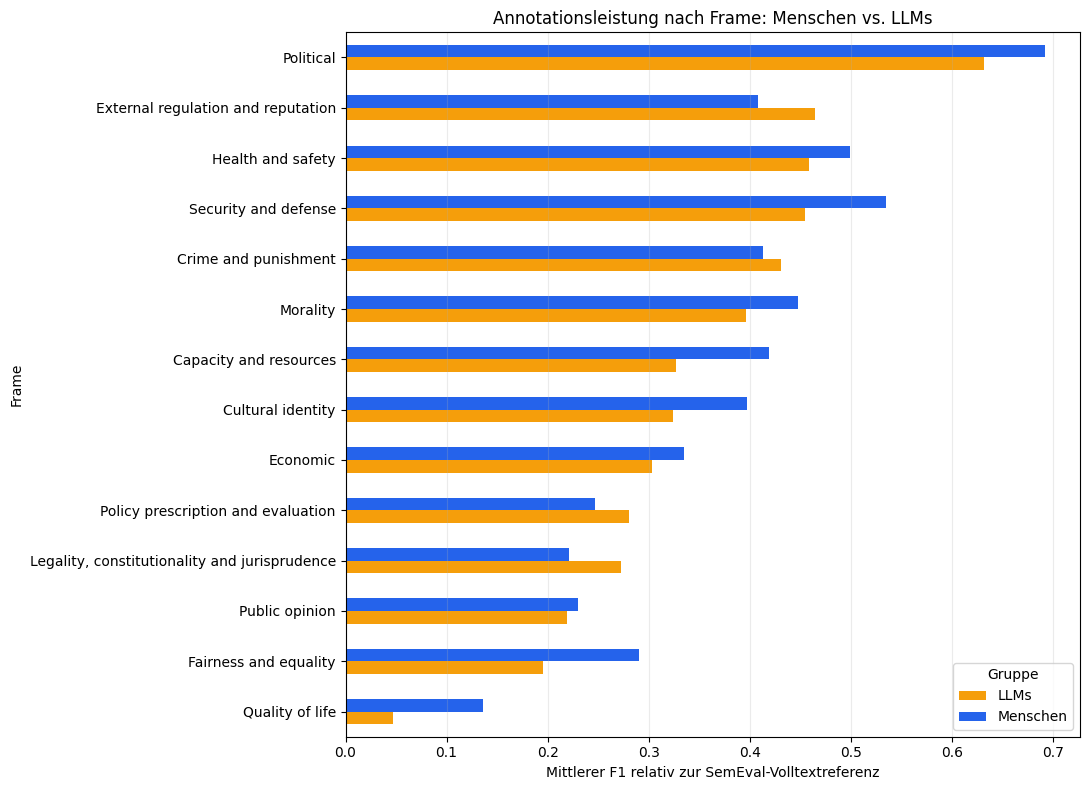

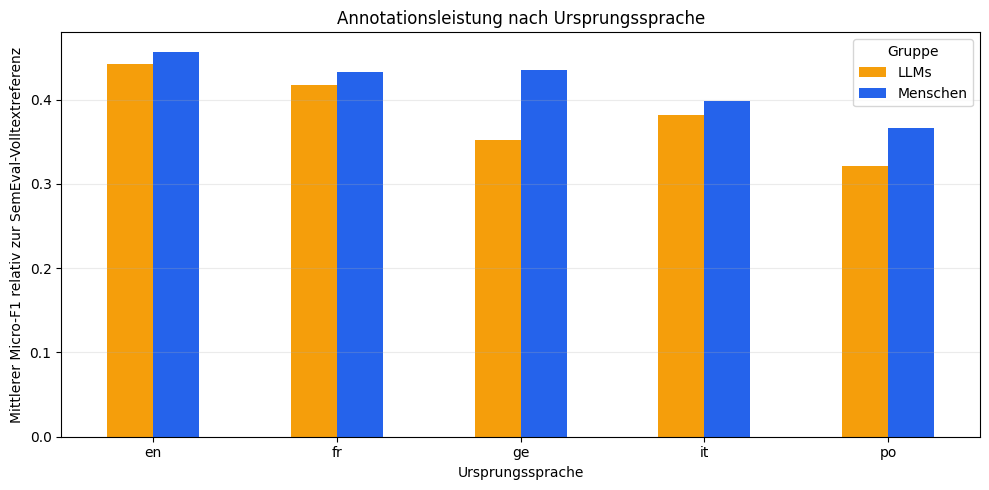

Erzeugte Dateien:
 - /content/drive/MyDrive/von neu/01 Annotationsstudie/01d Ergebnisse/01_annotationsstudie_ergebnisse.xlsx
 - /content/drive/MyDrive/von neu/01 Annotationsstudie/01d Ergebnisse/02_leistung_nach_frame.png
 - /content/drive/MyDrive/von neu/01 Annotationsstudie/01d Ergebnisse/03_leistung_nach_sprache.png
 - /content/drive/MyDrive/von neu/01 Annotationsstudie/01d Ergebnisse/04_zusammenfassung.txt


In [15]:
# Framevergleich
frame_plot = frame_group_summary.pivot(index='Frame', columns='Gruppe', values='F1_Mittel')
frame_plot = frame_plot.sort_values('LLMs' if 'LLMs' in frame_plot.columns else frame_plot.columns[0])
ax = frame_plot.plot(kind='barh', figsize=(11, 8), color=['#F59E0B', '#2563EB'])
ax.set_xlabel('Mittlerer F1 relativ zur SemEval-Volltextreferenz')
ax.set_ylabel('Frame')
ax.set_title('Annotationsleistung nach Frame: Menschen vs. LLMs')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
frame_figure = RESULTS_DIR / '02_leistung_nach_frame.png'
plt.savefig(frame_figure, dpi=180, bbox_inches='tight')
plt.show()

# Sprachvergleich
language_plot = language_group_summary.pivot(index='Sprache', columns='Gruppe', values='Micro_F1_Mittel')
ax = language_plot.plot(kind='bar', figsize=(10, 5), color=['#F59E0B', '#2563EB'])
ax.set_ylabel('Mittlerer Micro-F1 relativ zur SemEval-Volltextreferenz')
ax.set_xlabel('Ursprungssprache')
ax.set_title('Annotationsleistung nach Ursprungssprache')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
language_figure = RESULTS_DIR / '03_leistung_nach_sprache.png'
plt.savefig(language_figure, dpi=180, bbox_inches='tight')
plt.show()

excel_output = RESULTS_DIR / '01_annotationsstudie_ergebnisse.xlsx'
with pd.ExcelWriter(excel_output, engine='openpyxl') as writer:
    validation_summary.to_excel(writer, sheet_name='Validierung', index=False)
    agreement_summary.to_excel(writer, sheet_name='IAA_Gruppen', index=False)
    agreement_frames.to_excel(writer, sheet_name='IAA_nach_Frame', index=False)
    agreement_by_language.to_excel(writer, sheet_name='IAA_nach_Sprache', index=False)
    performance_overall.to_excel(writer, sheet_name='Leistung_Einzeln', index=False)
    performance_group_summary.to_excel(writer, sheet_name='Leistung_Gruppen', index=False)
    performance_by_frame.to_excel(writer, sheet_name='Frame_Einzeln', index=False)
    frame_group_summary.to_excel(writer, sheet_name='Frame_Gruppen', index=False)
    performance_by_language.to_excel(writer, sheet_name='Sprache_Einzeln', index=False)
    language_group_summary.to_excel(writer, sheet_name='Sprache_Gruppen', index=False)

summary_output = RESULTS_DIR / '04_zusammenfassung.txt'
best_human = performance_overall.loc[
    performance_overall.query("Gruppe == 'Menschen'")['Micro_F1'].idxmax()
]
best_llm = performance_overall.loc[
    performance_overall.query("Gruppe == 'LLMs'")['Micro_F1'].idxmax()
]

summary_lines = [
    'ANNOTATIONSSTUDIE – ZENTRALE AUSGABEN',
    '=' * 48,
    f'Artikel im Sample: {len(reference_ids)}',
    f'Menschliche Annotationen: {len(human_data)}',
    f'LLM-Annotationen: {len(llm_data)}',
    '',
    'Wichtiger Interpretationshinweis:',
    'Die Leistungsmetriken messen die Überlappung der Titelannotation mit der SemEval-Volltextannotation.',
    'Sie sind keine direkte Messung eines unabhängigen Titel-Goldstandards.',
    '',
    f'Höchster menschlicher Micro-F1: {best_human.Micro_F1:.4f} ({best_human.Annotator})',
    f'Höchster LLM-Micro-F1: {best_llm.Micro_F1:.4f} ({best_llm.Annotator})',
    '',
    'Detaillierte Ergebnisse nach Frame und Sprache befinden sich in 01_annotationsstudie_ergebnisse.xlsx.',
]
summary_output.write_text('\n'.join(summary_lines) + '\n', encoding='utf-8')

print('Erzeugte Dateien:')
for path in [excel_output, frame_figure, language_figure, summary_output]:
    print(' -', path)


## 9. Bedeutung für die nächste Projektphase

Die Ergebnisse dieses Notebooks werden in Phase 2 zur methodischen Begründung der Titelannotation verwendet. Insbesondere lässt sich prüfen, ob eine binäre Frame-Präsenz geeigneter ist als eine erzwungene Mainframe-Unterscheidung und ob eine LLM-Konsensregel als konservative Weak-Supervision-Grundlage vertretbar ist.

Die Phase-1-Dateien selbst werden in Phase 2 nicht verändert. Die spätere Titelannotation des gesamten Trainingsdatensatzes erfolgt in einem separaten Notebook und in den Ordnern unter **02 Modelltraining**.
